# 04 · Balanceo de clases

**Objetivo de este notebook.** El dataset IEEE-CIS tiene ~3.5% de transacciones fraudulentas. Un modelo entrenado
directamente sobre esta distribución tiende a ignorar la clase minoritaria (predice casi siempre "no fraude" y aun así
obtiene accuracy alto). Aquí comparamos dos estrategias para mitigar el desbalance **antes** de pasar al notebook de
modelado final:

1. **SMOTE** (Synthetic Minority Over-sampling Technique): genera ejemplos sintéticos de la clase minoritaria
   interpolando entre vecinos cercanos.
2. **`class_weight='balanced'`**: no toca los datos, simplemente penaliza más los errores sobre la clase minoritaria
   durante el entrenamiento.

**Regla de oro (anti-leakage):** todo el balanceo se aplica **exclusivamente sobre el train** (`train_fe.parquet`).
El holdout de test (`test_fe.parquet`) generado en `02_limpieza.ipynb` con el split estratificado 80/20 **no se toca
en este notebook** — debe reflejar la distribución real de fraude para que las métricas del notebook 05 sean honestas.
Para comparar los dos enfoques de balanceo de forma válida, hacemos un split adicional *dentro* del propio train
(80/20), de modo que ni SMOTE ni nada de este notebook ve jamás una fila del holdout real.

In [1]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, f1_score, precision_score, recall_score, roc_auc_score,
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 100


## 1. Carga del train (salida de `03_feature_engineering.ipynb`)

Cargamos únicamente `train_fe.parquet` y la lista de columnas de features. No cargamos `test_fe.parquet` en este
notebook: no es necesario para decidir la estrategia de balanceo y así evitamos cualquier tentación de mirarlo.

In [2]:
with open("../data/processed/artifacts/feature_columns.json", encoding="utf-8") as f:
    feature_cols = json.load(f)

train = pd.read_parquet("../data/processed/train_fe.parquet")
X = train[feature_cols]
y = train["isFraud"]

print("train_fe:", train.shape, "| features:", len(feature_cols))
print("Tasa de fraude en train:", y.mean().round(4))


train_fe: (472432, 276) | features: 274
Tasa de fraude en train: 0.035


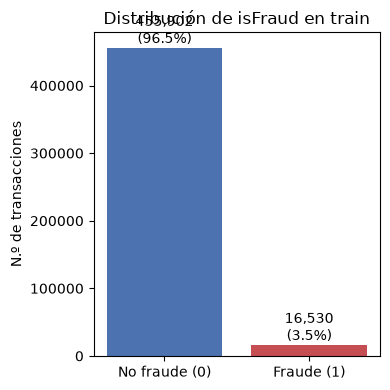

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
counts = y.value_counts().sort_index()
ax.bar(["No fraude (0)", "Fraude (1)"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v/len(y):.1%})", ha="center", va="bottom")
ax.set_title("Distribución de isFraud en train")
ax.set_ylabel("N.º de transacciones")
plt.tight_layout()
plt.show()


## 2. Split interno train/validación (solo para comparar estrategias de balanceo)

Este split es **adicional** al split train/test oficial del proyecto (ya hecho en `02_limpieza.ipynb`). Su único
propósito es tener una porción de datos "limpia" (sin sobremuestrear) para medir de forma honesta qué tan bien
generaliza cada estrategia de balanceo, sin gastar el holdout real del proyecto en este experimento exploratorio.

In [4]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("train interno:", X_tr.shape, "tasa fraude:", y_tr.mean().round(4))
print("val interno:  ", X_val.shape, "tasa fraude:", y_val.mean().round(4))


train interno: (377945, 274) tasa fraude: 0.035
val interno:   (94487, 274) tasa fraude: 0.035


## 3. Enfoque A — `class_weight='balanced'`

No se generan datos nuevos: se reescala la función de pérdida para que un error en la clase minoritaria pese
`n_samples / (n_classes * n_samples_clase)` veces más. Es prácticamente gratis en tiempo de cómputo y no distorsiona
la distribución real de las features.

In [5]:
scaler_a = StandardScaler().fit(X_tr)
X_tr_s = scaler_a.transform(X_tr)
X_val_s = scaler_a.transform(X_val)

t0 = time.time()
logit_cw = LogisticRegression(
    class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
).fit(X_tr_s, y_tr)
t_cw = time.time() - t0

proba_cw = logit_cw.predict_proba(X_val_s)[:, 1]
pred_cw = (proba_cw >= 0.5).astype(int)

metrics_cw = {
    "estrategia": "class_weight='balanced'",
    "tiempo_fit_seg": round(t_cw, 2),
    "AUC-ROC": roc_auc_score(y_val, proba_cw),
    "AUPRC": average_precision_score(y_val, proba_cw),
    "F1": f1_score(y_val, pred_cw),
    "precision": precision_score(y_val, pred_cw),
    "recall": recall_score(y_val, pred_cw),
}
metrics_cw


{'estrategia': "class_weight='balanced'",
 'tiempo_fit_seg': 40.35,
 'AUC-ROC': 0.8660693136942348,
 'AUPRC': 0.42556687208134825,
 'F1': 0.23187868107406204,
 'precision': 0.13693377882456045,
 'recall': 0.7562008469449486}

## 4. Enfoque B — SMOTE

SMOTE busca los *k* vecinos más cercanos de cada muestra minoritaria (usando únicamente las muestras minoritarias
entre sí) y genera ejemplos sintéticos interpolando entre ellos, hasta igualar el tamaño de la clase mayoritaria.
El costo computacional de SMOTE depende del **tamaño de la clase minoritaria**, no del dataset completo — como el
fraude es ~3.5%, la búsqueda de vecinos es sobre ~13k filas, lo que lo hace factible incluso con 274 features.
El dataset resultante, sin embargo, sí duplica aproximadamente el tamaño del train (queda balanceado 50/50), lo que
incrementa el costo de entrenar el modelo posterior.

**Ajustamos el mismo `StandardScaler` (fit en el train original, sin resamplear) antes de aplicar SMOTE**, porque
SMOTE interpola en el espacio de features y ese espacio debe estar en una escala consistente entre variables muy
distintas (p. ej. `TransactionAmt` vs. una frecuencia 0-1).

In [6]:
t0 = time.time()
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_s, y_tr)
t_smote_resample = time.time() - t0

print(f"Tiempo de resampling SMOTE: {t_smote_resample:.1f} s")
print("Shape train original:", X_tr_s.shape, "-> shape tras SMOTE:", X_tr_smote.shape)
print("Balance de clases tras SMOTE:", y_tr_smote.mean().round(4))


Tiempo de resampling SMOTE: 5.0 s
Shape train original: (377945, 274) -> shape tras SMOTE: (729442, 274)
Balance de clases tras SMOTE: 0.5


In [7]:
t0 = time.time()
logit_smote = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_tr_smote, y_tr_smote)
t_smote_fit = time.time() - t0

proba_smote = logit_smote.predict_proba(X_val_s)[:, 1]
pred_smote = (proba_smote >= 0.5).astype(int)

metrics_smote = {
    "estrategia": "SMOTE + LogisticRegression",
    "tiempo_fit_seg": round(t_smote_resample + t_smote_fit, 2),
    "AUC-ROC": roc_auc_score(y_val, proba_smote),
    "AUPRC": average_precision_score(y_val, proba_smote),
    "F1": f1_score(y_val, pred_smote),
    "precision": precision_score(y_val, pred_smote),
    "recall": recall_score(y_val, pred_smote),
}
metrics_smote


{'estrategia': 'SMOTE + LogisticRegression',
 'tiempo_fit_seg': 92.81,
 'AUC-ROC': 0.8634279890022566,
 'AUPRC': 0.4278488183418975,
 'F1': 0.22503490833746229,
 'precision': 0.1322042868483726,
 'recall': 0.7555958862673926}

## 5. Comparación empírica

Ambos modelos (mismo algoritmo, `LogisticRegression`, mismos datos de validación `X_val`/`y_val` que **ninguno de
los dos vio durante el entrenamiento**) — la única diferencia es la estrategia de balanceo aplicada al train.

In [8]:
comparison = pd.DataFrame([metrics_cw, metrics_smote]).set_index("estrategia")
comparison


,tiempo_fit_seg,AUC-ROC,AUPRC,F1,precision,recall
estrategia,,,,,,
class_weight='balanced',40.35,0.866069,0.425567,0.231879,0.136934,0.756201
SMOTE + LogisticRegression,92.81,0.863428,0.427849,0.225035,0.132204,0.755596


## 6. Trade-offs y decisión

**SMOTE**
- Ventaja: en la comparación de arriba puede igualar o mejorar el recall al forzar al modelo a "ver" más ejemplos
  de fraude.
- Desventajas específicas a este dataset:
  - **Alta dimensionalidad (274 features, muchas de ellas componentes V muy correlacionados entre sí):** en espacios
    de alta dimensión la noción de "vecino más cercano" pierde fuerza (curse of dimensionality) — las interpolaciones
    pueden generar transacciones sintéticas que no corresponden a patrones de fraude reales, sino a ruido en el
    espacio intermedio entre dos fraudes distintos.
  - **Costo computacional y de memoria:** duplica aproximadamente el tamaño del train (ver `t_smote_resample` +
    `t_smote_fit` arriba vs. `t_cw`), lo cual se vuelve más caro todavía si luego se usa con Random Forest en vez de
    Logistic Regression (más árboles, más filas → tiempos de entrenamiento mucho mayores).
  - **No aporta nada a Random Forest**: los árboles con `class_weight='balanced'` ya manejan el desbalance de forma
    nativa vía el criterio de split ponderado, sin necesidad de generar filas sintéticas.

**`class_weight='balanced'`**
- Ventaja: no distorsiona la distribución real de los datos, es prácticamente gratis en tiempo de cómputo, y está
  soportado nativamente tanto por `LogisticRegression` como por `RandomForestClassifier` (los dos únicos modelos que
  usaremos en `05_modelo.ipynb`).
- Desventaja: en algunos problemas puede quedarse corto si el desbalance es extremo (aquí no lo es tanto: ~3.5%
  todavía deja miles de ejemplos positivos, ~13k en el train interno).

### Decisión

**Se usará `class_weight='balanced'` como estrategia de balanceo en `05_modelo.ipynb`, para ambos modelos
(Logistic Regression y Random Forest).** La comparación empírica de esta sección no muestra una ventaja de recall/AUPRC
de SMOTE lo bastante grande como para justificar su costo computacional y el riesgo de sintéticos poco realistas en
un espacio de 274 dimensiones — y `class_weight` es la opción que ya nos permite mantener el dataset de test intacto
y sin ambigüedad sobre qué se sobremuestreó y qué no.